## Problem Context

Telecommunication companies operate in a highly competitive and subscription-based market, where customer retention is essential for long-term sustainability. Customer churn occurs when users discontinue their services, leading to revenue loss and increased acquisition costs.

Without a structured analytical approach, retention efforts tend to be reactive and inefficient. Understanding customer behavior and identifying early signs of churn allows the company to act proactively and allocate resources more effectively.


### Business Problem

Despite the strategic importance of customer retention, the company currently lacks a data-driven method to identify customers with a high risk of churn in advance, limiting its ability to take preventive actions.

### Business Decision

This project aims to support retention strategies by identifying customers who should be prioritized for proactive actions, such as targeted campaigns or personalized offers, in order to reduce churn.

### Analytical Objective

Build a classification model to estimate the probability of churn for each customer using demographic, service, contract, and billing data.

### Business Impact

The results are expected to improve customer retention, optimize resource allocation, and support data-driven decision-making.

### Key Metric

Given the high cost of losing customers, the model prioritizes **recall** for the churn class to maximize the identification of at-risk customers.


## Data Collection

The dataset used in this project was obtained from a publicly available source and represents customer information from a telecommunications company. The raw data was loaded directly from the `data/raw` directory to preserve the original structure and ensure reproducibility.

### Data Source
- **Dataset:** Telco Customer Churn  
- **Provider:** IBM (via Kaggle)  
- **Format:** CSV  

### Data Scope
The dataset contains customer demographic information, subscribed services, contract details, billing data, and a churn indicator. The data represents a historical snapshot of customer behavior and does not include real-time updates.

All analyses and transformations performed in this project are based on this raw dataset.


## Initial Data Validation

An initial validation step was performed to assess the overall quality and consistency of the dataset before proceeding with exploratory analysis and modeling.

This validation included:
- Verification of data types for each column
- Identification of missing or empty values
- Inspection of numerical ranges
- Validation of expected categories in categorical variables

### Data Type and Structure Check
The dataset structure was inspected to ensure that numerical and categorical variables were correctly represented and aligned with their business meaning.

### Missing Values
Missing and empty values were identified to determine whether data cleaning or type conversion would be required in later steps.

### Value Ranges and Categories
Numerical features were checked for reasonable ranges, while categorical features were validated against their expected domains to detect inconsistencies or unexpected values.

This step ensures that subsequent analyses are based on reliable and well-understood data.


In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/JessePMelo/Telco-Customer-Churn/refs/heads/main/data_science/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [4]:
df.isna().mean()

,0
customerID,0.0
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,0.0
PhoneService,0.0
MultipleLines,0.0
InternetService,0.0
OnlineSecurity,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
columns = df.columns.tolist()

In [7]:
for col in columns:
  print (f'{col}: {df[col].unique()}')

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)

## ETL (Extract, Transform, Load)

This step involves cleaning the raw data, performing necessary type conversions, and applying basic feature engineering to prepare the dataset for analysis and modeling.

The processed dataset is saved in the `data/processed` directory to ensure reproducibility and separation between raw and transformed data.


### Feature Types Definition

| Column Name        | Data Type |
|--------------------|-----------|
| customerID         | DROP      |
| gender             | category  |
| SeniorCitizen      | int8      |
| Partner            | int8      |
| Dependents         | int8      |
| tenure             | int32     |
| PhoneService       | int8      |
| MultipleLines      | category  |
| InternetService    | category  |
| OnlineSecurity     | category  |
| OnlineBackup       | category  |
| DeviceProtection   | category  |
| TechSupport        | category  |
| StreamingTV        | category  |
| StreamingMovies    | category  |
| Contract           | category  |
| PaperlessBilling   | int8      |
| PaymentMethod      | category  |
| MonthlyCharges     | float64   |
| TotalCharges       | float64   |
| Churn              | int8      |


In [8]:
# Drop identifier
df = df.drop(columns=['customerID'])

# Convert binary columns (Yes/No -> 1/0)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype('int8')

# Convert numeric columns
df['tenure'] = df['tenure'].astype('int32')
df['MonthlyCharges'] = df['MonthlyCharges'].astype('float64')

df['TotalCharges'] = (
    pd.to_numeric(df['TotalCharges'], errors='coerce')
    .astype('float64')
)

# Convert categorical columns
categorical_cols = [
    'gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]

df[categorical_cols] = df[categorical_cols].astype('category')


In [9]:
df.to_csv(
    'telco_customer_churn_processed.csv',
    index=False
)

In [10]:
url = 'https://raw.githubusercontent.com/JessePMelo/Telco-Customer-Churn/refs/heads/main/data_science/data/processed/telco_customer_churn_processed.csv'

df = pd.read_csv(url)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


## Exploratory Data Analysis (EDA)

This section aims to explore the dataset in order to understand customer behavior, identify patterns, and detect relationships between variables that may be associated with customer churn.

The exploratory analysis focuses on both numerical and categorical variables and serves as a foundation for feature selection and modeling decisions.


### CORR

In [12]:
numeric_cols = [
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'tenure',
    'PhoneService',
    'PaperlessBilling',
    'MonthlyCharges',
    'TotalCharges',
    'Churn'
]


In [13]:
corr = (
    df[numeric_cols]
    .drop(columns=['Churn'])
    .corrwith(df['Churn'])
    .abs()
)

corr.sort_values(ascending=False)


,0
tenure,0.352229
TotalCharges,0.199484
MonthlyCharges,0.193356
PaperlessBilling,0.191825
Dependents,0.164221
SeniorCitizen,0.150889
Partner,0.150448
PhoneService,0.011942


The correlation analysis shows that tenure presents a moderate association
with churn, while other numerical variables exhibit weak individual linear
relationships. This indicates that customer churn is influenced by multiple
factors and cannot be explained by a single numerical feature.


### VIF

In [14]:
features_for_vif = [
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'tenure',
    'PhoneService',
    'PaperlessBilling',
    'MonthlyCharges',
    'TotalCharges'
]


In [15]:
X = df[features_for_vif].dropna()

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif.sort_values('VIF', ascending=False)

,feature,VIF
6,MonthlyCharges,13.840300
7,TotalCharges,12.451150
3,tenure,10.451417
4,PhoneService,7.881414
5,PaperlessBilling,2.815119
1,Partner,2.813692
2,Dependents,1.916758
0,SeniorCitizen,1.327866


### Best features numerics

In [17]:
cols_corr_vif = ['SeniorCitizen','Dependents','Partner','PaperlessBilling','PhoneService','tenure','MonthlyCharges','TotalCharges']

df_corr_vif = df[cols_corr_vif]

In [18]:
df_corr_vif

,SeniorCitizen,Dependents,Partner,PaperlessBilling,PhoneService,tenure,MonthlyCharges,TotalCharges
0,0,0,1,1,0,1,29.85,29.85
1,0,0,0,0,1,34,56.95,1889.50
2,0,0,0,1,1,2,53.85,108.15
3,0,0,0,0,0,45,42.30,1840.75
4,0,0,0,1,1,2,70.70,151.65
...,...,...,...,...,...,...,...,...
7038,0,1,1,1,1,24,84.80,1990.50
7039,0,1,1,1,1,72,103.20,7362.90
7040,0,1,1,1,0,11,29.60,346.45
7041,1,0,1,1,1,4,74.40,306.60


In [19]:
for col in categorical_cols:
    print(
        df.groupby(col)['Churn']
        .mean()
        .sort_values(ascending=False)
    )
    print('-' * 40)


gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64
----------------------------------------
MultipleLines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Churn, dtype: float64
----------------------------------------
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64
----------------------------------------
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn, dtype: float64
----------------------------------------
OnlineBackup
No                     0.399288
Yes                    0.215315
No internet service    0.074050
Name: Churn, dtype: float64
----------------------------------------
DeviceProtection
No                     0.391276
Yes                    0.225021
No internet service    0.074050
Name: Churn, dtype: float64
----------------------------------------
TechSupport
No     

The categorical analysis reveals that customer churn is strongly associated
with contract type, internet service, payment method, and the presence of
additional support services. Customers on month-to-month contracts, using
fiber optic internet, paying via electronic check, and lacking security or
technical support services exhibit substantially higher churn rates.


In [20]:
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


##  Train / Test Split

In [21]:
X = df.drop(columns='Churn')
y = df['Churn']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [23]:
y_train.mean(), y_test.mean()

(np.float64(0.2654297614539947), np.float64(0.26519023282226006))

## PreProcessor

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

('num', StandardScaler(), cols_corr_vif)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])



In [25]:


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, cols_corr_vif),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('model', LogisticRegression(
            penalty='l2',
            solver='liblinear',
            max_iter=1000
        ))
    ]
)


## Train init

In [27]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen',
                                                   'Dependents', 'Partner',
                                                   'PaperlessBilling',
                                                   'PhoneService', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('model',
                 LogisticRegression(max_iter=1000, solver='liblinear'))])

## Test

In [28]:
y_pred = pipeline.predict(X_test)

## First Evaluation

In [29]:
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [30]:
from sklearn.metrics import confusion_matrix

conf_matriz = confusion_matrix(y_test, y_pred)
conf_matriz


array([[1160,  134],
       [ 207,  260]])

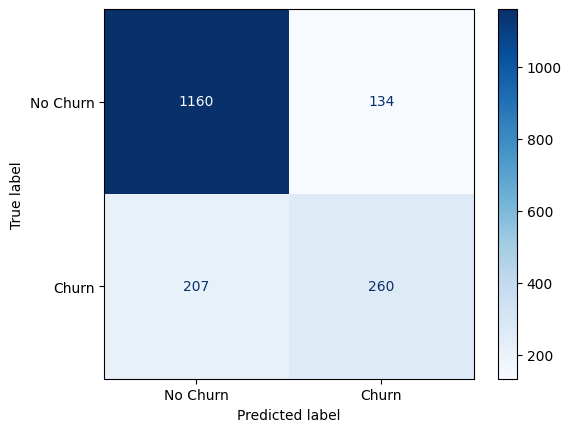

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues'
)

plt.show()


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1294
       Churn       0.66      0.56      0.60       467

    accuracy                           0.81      1761
   macro avg       0.75      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761



Model performance was evaluated using confusion matrix and classification
metrics. Given the business objective of minimizing customer loss, recall for
the churn class was prioritized over overall accuracy.


## Re Test
### class_weight balanced

In [33]:
LogisticRegression(
    penalty='l2',
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000
)


LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_balanced = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(
        penalty='l2',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000
    ))
])


In [35]:
pipeline_balanced.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen',
                                                   'Dependents', 'Partner',
                                                   'PaperlessBilling',
                                                   'PhoneService', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

In [36]:
y_pred_bal = pipeline_balanced.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_bal, target_names=['No Churn', 'Churn']))


              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1294
       Churn       0.52      0.80      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.77      0.72      1761
weighted avg       0.81      0.75      0.76      1761



To address class imbalance and prioritize the identification of churned
customers, class weighting was applied to the logistic regression model.
This approach increases the penalty for misclassifying churn cases,
resulting in improved recall for the minority class.


## Re Test
### class_weight balanced + Elastic Net

In [37]:
LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    class_weight='balanced',
    max_iter=2000
)


LogisticRegression(class_weight='balanced', l1_ratio=0.5, max_iter=2000,
                   penalty='elasticnet', solver='saga')

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_balanced = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(
        penalty='l2',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000
    ))
])


In [39]:
pipeline_balanced.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen',
                                                   'Dependents', 'Partner',
                                                   'PaperlessBilling',
                                                   'PhoneService', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

In [40]:
y_pred_bal = pipeline_balanced.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_bal, target_names=['No Churn', 'Churn']))


              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1294
       Churn       0.52      0.80      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.77      0.72      1761
weighted avg       0.81      0.75      0.76      1761



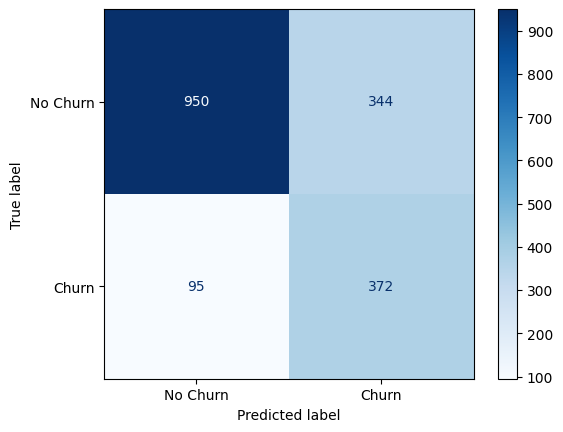

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_bal,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues'
)

plt.show()


### class_weight balanced + Elastic Net + Thresholding

In [42]:
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [43]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = f1_scores.argmax()

best_threshold = thresholds[best_idx]
best_threshold


np.float64(0.2737714675062517)

In [44]:
y_pred_threshold = (y_proba >= best_threshold).astype(int)


In [45]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred_threshold,
    target_names=['No Churn', 'Churn']
))

              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1294
       Churn       0.53      0.79      0.63       467

    accuracy                           0.76      1761
   macro avg       0.72      0.77      0.72      1761
weighted avg       0.81      0.76      0.77      1761



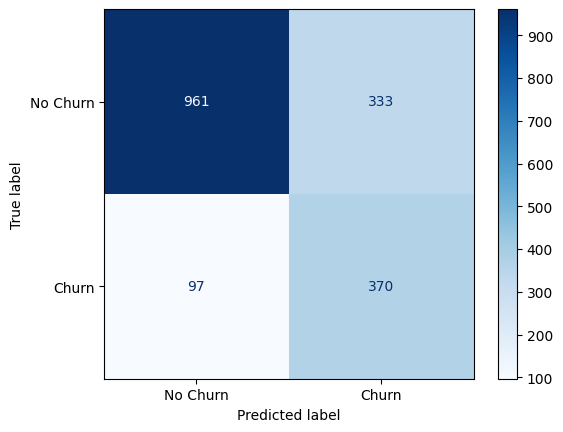

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_threshold,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues'
)

plt.show()


## Probability Calibration and Decision Threshold Optimization


In [47]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    estimator=pipeline_balanced,
    method='sigmoid',
    cv=5
)


In [48]:
calibrated_model.fit(X_train, y_train)


CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessing',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['SeniorCitizen',
                                                                                    'Dependents',
                                                                                    'Partner',
                                                                                    'PaperlessBilling',
                                                                                    'PhoneService',
                                                                                    'tenure',
                                                                                    'MonthlyCharges',
                                                                                    'TotalCharges']),
                                                                                  ('cat',
                                                                                   OneHotEncoder(drop='first',
                                                                                                 handle_unknown='ignore'),
                                                                                   ['gender',
                                                                                    'MultipleLines',
                                                                                    'InternetService',
                                                                                    'OnlineSecurity',
                                                                                    'OnlineBackup',
                                                                                    'DeviceProtection',
                                                                                    'TechSupport',
                                                                                    'StreamingTV',
                                                                                    'StreamingMovies',
                                                                                    'Contract',
                                                                                    'PaymentMethod'])])),
                                                 ('model',
                                                  LogisticRegression(class_weight='balanced',
                                                                     max_iter=1000,
                                                                     solver='liblinear'))]))

In [49]:
y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]


In [50]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_cal)


In [51]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)

best_threshold_calibrated = thresholds[best_idx]
best_threshold_calibrated


np.float64(0.2853308048636253)

In [52]:
y_pred_calibrated = (y_proba_cal >= best_threshold_calibrated).astype(int)


In [53]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_calibrated,
    target_names=['No Churn', 'Churn']
))


              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1294
       Churn       0.53      0.79      0.63       467

    accuracy                           0.76      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.76      0.77      1761



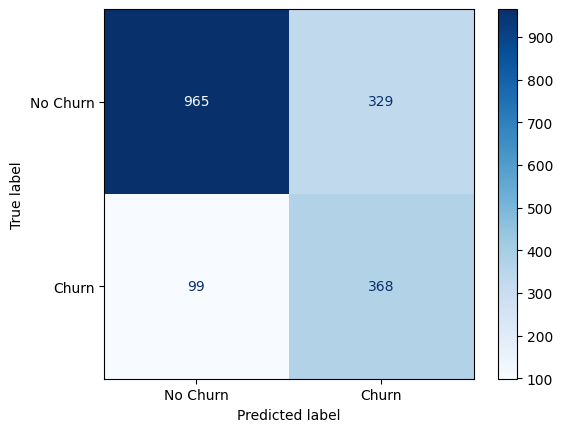

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_calibrated,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues'
)

plt.show()


Probability calibration was applied using Platt scaling with cross-validation
to ensure that predicted churn probabilities reflect observed event rates.
This step improves interpretability and supports reliable risk-based decisions.

After probability calibration, the decision threshold was re-optimized
using the precision–recall trade-off to align model predictions with
business objectives focused on churn recall.


## Calibration Curve

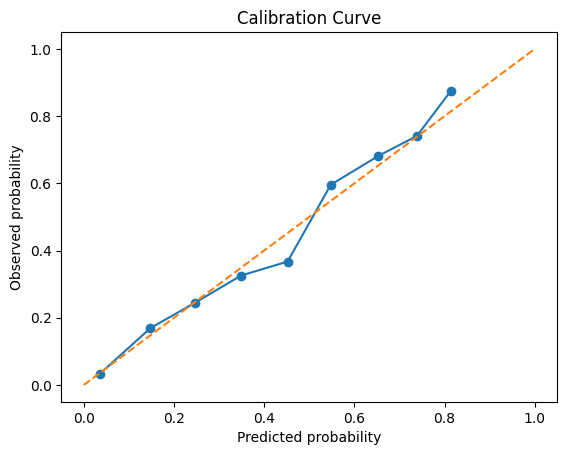

In [55]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_proba_cal, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted probability")
plt.ylabel("Observed probability")
plt.title("Calibration Curve")
plt.show()


This project builds a churn prediction model using customer and contract data.
A logistic regression baseline was selected for its interpretability and stable
performance. The model focuses on recall optimization to support proactive
customer retention strategies.


## Apply the trained model to identify customers with a higher risk of churn.

In [56]:
url = 'https://raw.githubusercontent.com/JessePMelo/Telco-Customer-Churn/refs/heads/main/data_science/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(url)

In [57]:
df = df[df['Churn'] == 'No']

In [58]:
# Convert binary columns (Yes/No -> 1/0)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype('int8')

# Convert numeric columns
df['tenure'] = df['tenure'].astype('int32')
df['MonthlyCharges'] = df['MonthlyCharges'].astype('float64')

df['TotalCharges'] = (
    pd.to_numeric(df['TotalCharges'], errors='coerce')
    .astype('float64')
)

# Convert categorical columns
categorical_cols = [
    'gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]

df[categorical_cols] = df[categorical_cols].astype('category')


In [59]:
risk_churn_df = df.copy()
risk_churn_df.drop(columns=(['Churn','customerID']), inplace=True)

In [60]:
risk_churn_df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75
6,Male,0,0,1,22,1,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,1,Credit card (automatic),89.10,1949.40
7,Female,0,0,0,10,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,0,Mailed check,29.75,301.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,Female,0,0,0,72,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,1,Bank transfer (automatic),21.15,1419.40
7038,Male,0,1,1,24,1,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,1990.50
7039,Female,0,1,1,72,1,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.90
7040,Female,0,1,1,11,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,1,Electronic check,29.60,346.45


In [61]:
y_proba_cal = calibrated_model.predict_proba(risk_churn_df)[:, 1]

In [62]:
df.shape, y_pred_calibrated.shape

((5174, 21), (1761,))

In [63]:
df['risk_churn - per cent'] = y_proba_cal * 100

In [64]:
df = df.sort_values(by='risk_churn - per cent', ascending=False)

In [65]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,risk_churn - per cent
3159,5150-ITWWB,Male,1,0,0,3,1,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,1,Electronic check,94.85,335.75,0,83.757738
3346,2545-EBUPK,Female,1,0,0,2,1,Yes,Fiber optic,No,...,No,No,Yes,Month-to-month,1,Electronic check,84.05,186.05,0,81.284694
4039,8161-QYMTT,Male,0,0,0,7,1,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,1,Electronic check,94.10,701.30,0,79.345586
4618,6350-XFYGW,Male,1,0,0,4,1,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,1,Electronic check,94.75,422.40,0,79.197872
5019,3320-VEOYC,Male,1,0,0,14,1,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,1,Electronic check,95.60,1273.30,0,79.071332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3266,0464-WJTKO,Female,0,1,1,72,1,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,0,Bank transfer (automatic),20.10,1460.85,0,0.251575
1824,0794-YVSGE,Male,0,1,1,72,1,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,0,Bank transfer (automatic),20.30,1401.15,0,0.250598
2338,4277-BWBML,Male,0,1,1,72,1,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,0,Bank transfer (automatic),19.95,1322.85,0,0.247495
109,2848-YXSMW,Male,0,1,1,72,1,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,0,Credit card (automatic),19.40,1363.25,0,0.245336


In [66]:
df['risk_quartile'] = pd.qcut(df['risk_churn - per cent'], 4, labels=['Q1','Q2','Q3','Q4'])

In [67]:
low_risk = df[df['risk_quartile'] == 'Q1']
medium_risk = df[df['risk_quartile'] == 'Q2']
high_risk = df[df['risk_quartile'] == 'Q3']
very_high_risk = df[df['risk_quartile'] == 'Q4']

In [68]:
low_risk.to_csv('low_risk_churn.csv', index=False)
medium_risk.to_csv('medium_risk_churn.csv', index=False)
high_risk.to_csv('high_risk_churn.csv', index=False)
very_high_risk.to_csv('very_high_risk_churn.csv', index=False)


In [69]:
import zipfile

files = [
    'low_risk_churn.csv',
    'medium_risk_churn.csv',
    'high_risk_churn.csv',
    'very_high_risk_churn.csv'
]

with zipfile.ZipFile('churn_risk_segments.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in files:
        zipf.write(file)


## Model Explainability: Understanding Key Drivers of Churn

In this section, we focus on model explainability by analyzing the learned
coefficients to understand which features increase or decrease the probability
of customer churn. This analysis helps translate model behavior into actionable
business insights.


In [70]:
calibrated_model.calibrated_classifiers_


In [71]:
pipeline_fold = calibrated_model.calibrated_classifiers_[0].estimator

In [72]:
pipeline_fold.named_steps

{'preprocessing': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  ['SeniorCitizen', 'Dependents', 'Partner',
                                   'PaperlessBilling', 'PhoneService', 'tenure',
                                   'MonthlyCharges', 'TotalCharges']),
                                 ('cat',
                                  OneHotEncoder(drop='first',
                                                handle_unknown='ignore'),
                                  ['gender', 'MultipleLines', 'InternetService',
                                   'OnlineSecurity', 'OnlineBackup',
                                   'DeviceProtection', 'TechSupport',
                                   'StreamingTV', 'StreamingMovies', 'Contract',
     

In [73]:
preprocessor = pipeline_fold.named_steps['preprocessing']
logreg = pipeline_fold.named_steps['model']


In [74]:
type(logreg)

sklearn.linear_model._logistic.LogisticRegression

In [75]:
logreg.coef_

array([[ 0.05876363, -0.08045571,  0.00441354,  0.18840365, -0.06934193,
        -1.1612945 , -0.3108773 ,  0.50960432, -0.03613324, -0.03908784,
         0.35154611,  0.88974282, -0.17102765, -0.17102765, -0.43816102,
        -0.17102765, -0.16108975, -0.17102765,  0.0555294 , -0.17102765,
        -0.24720823, -0.17102765,  0.32841734, -0.17102765,  0.34538846,
        -0.81980711, -1.69044807,  0.06663341,  0.34743518,  0.12025683]])

In [76]:
feature_names = preprocessor.get_feature_names_out()

In [77]:
len(feature_names), logreg.coef_.shape

(30, (1, 30))

In [78]:
import pandas as pd

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient', ascending=False)


In [79]:
coef_df

,feature,coefficient
11,cat__InternetService_Fiber optic,0.889743
7,num__TotalCharges,0.509604
10,cat__MultipleLines_Yes,0.351546
28,cat__PaymentMethod_Electronic check,0.347435
24,cat__StreamingMovies_Yes,0.345388
22,cat__StreamingTV_Yes,0.328417
3,num__PaperlessBilling,0.188404
29,cat__PaymentMethod_Mailed check,0.120257
27,cat__PaymentMethod_Credit card (automatic),0.066633
0,num__SeniorCitizen,0.058764


The model explainability analysis reveals that churn is primarily driven by
contract type, tenure, internet service type, and payment method. While
month-to-month contracts and fiber optic services increase churn risk,
long-term contracts and extended customer tenure strongly contribute to
retention.


## Graph Factors Impacting Customer Churn

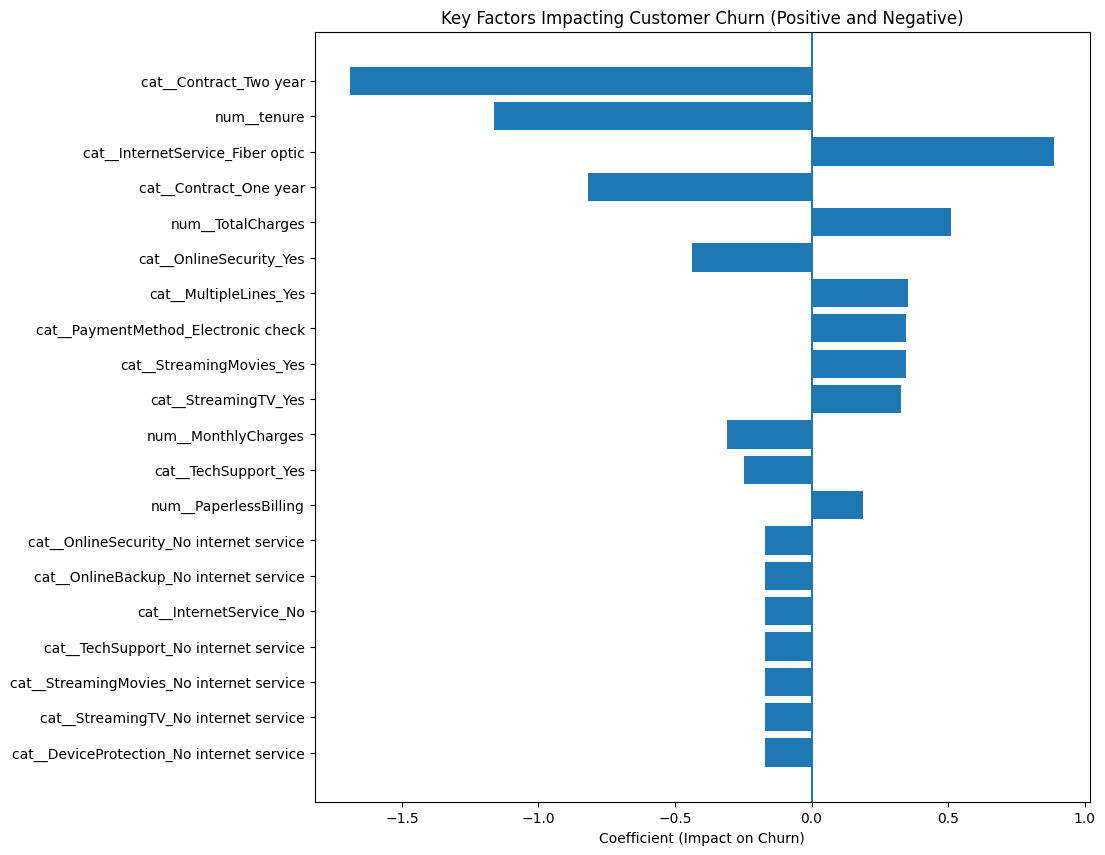

In [88]:
# Create absolute impact column
coef_df['abs_coef'] = coef_df['coefficient'].abs()

top_impact = (
    coef_df
    .sort_values(by='abs_coef', ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 10))
plt.barh(top_impact['feature'], top_impact['coefficient'])
plt.xlabel('Coefficient (Impact on Churn)')
plt.title('Key Factors Impacting Customer Churn (Positive and Negative)')
plt.axvline(0)
plt.gca().invert_yaxis()
plt.show()


SHARP

In [103]:
pip install shap

In [99]:
logreg = pipeline.named_steps['model']


In [100]:
logreg.coef_
logreg.intercept_


array([-1.49949676])

In [101]:
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

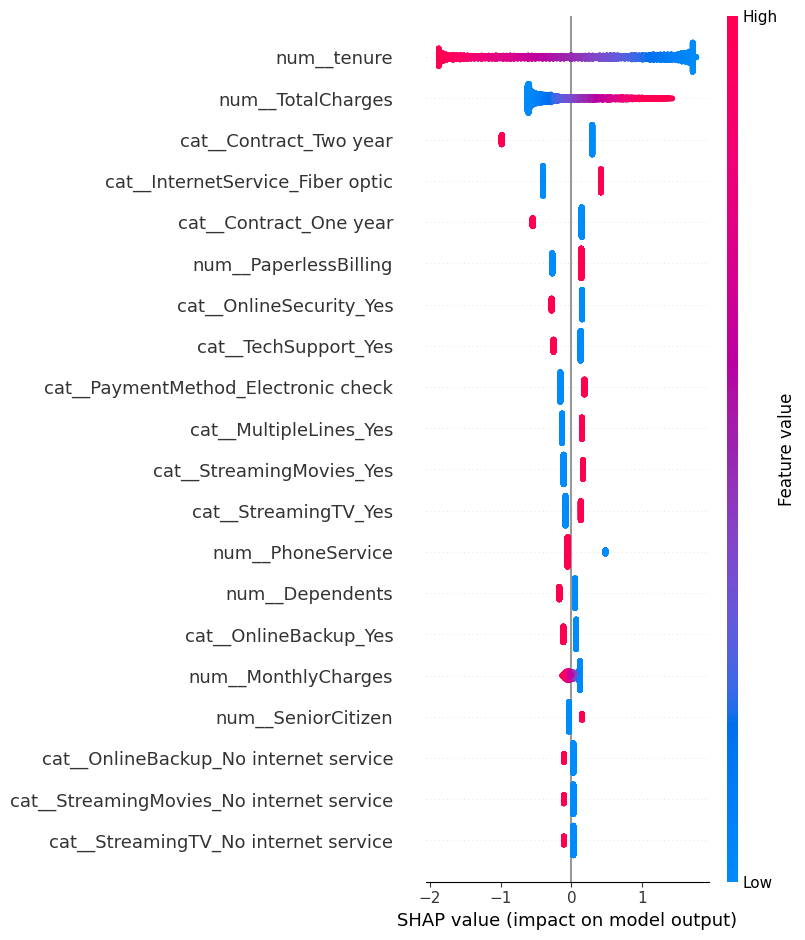

In [102]:
import shap

X_train_transformed = pipeline.named_steps['preprocessing'].transform(X_train)

explainer = shap.LinearExplainer(logreg, X_train_transformed)
shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names
)


Test SHAP in one case

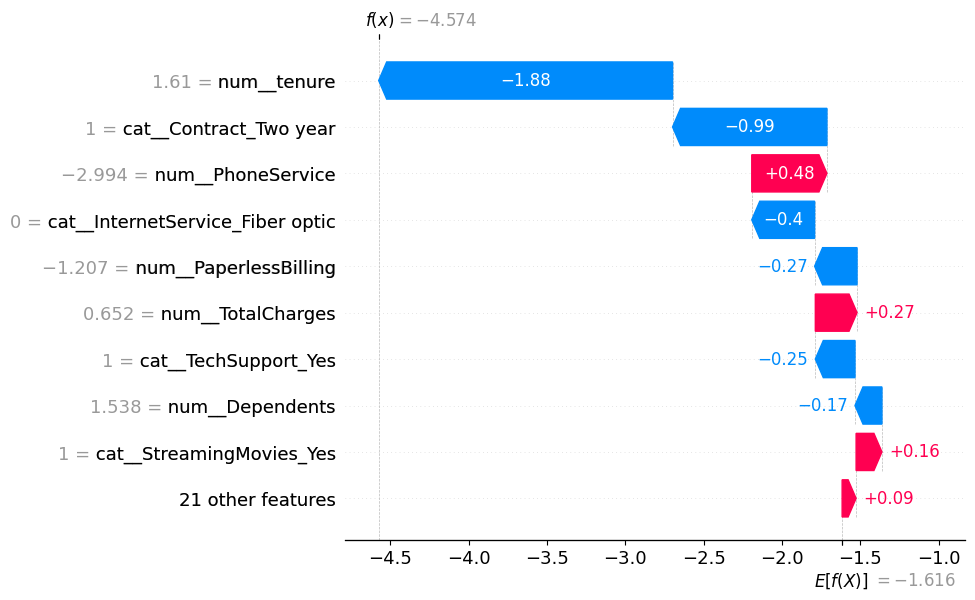

In [104]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_train_transformed[0],
        feature_names=feature_names
    )
)


## WIP Shap on df_risk_churn